In [19]:
import numpy as np
import pandas as pd
import math
from uncertainties import unumpy as unp
from uncertainties import ufloat as uf
import numpy as np
import uncertainties.umath as umath
import matplotlib.pyplot as plt
from scipy import stats


In [25]:
class info:
    height=uf(1.116, 0.002) #m
    puley_r = uf(24, 0.1)/1000 #m
    g_acc = 9.81
    out_radius = uf(15.00, 0.05)/100 #cm DUMMY VALUE
    in_radius = uf(10.00, 0.05)/100
    
raw = pd.read_csv("visc.csv")
print(raw)

   ang_velocity_radps  mass_g
0                2.70    10.0
1                9.20    20.0
2               14.60    30.0
3               19.82    39.9
4               24.57    50.1
5               29.50    60.0
6               34.50    70.0
7               39.20    80.0


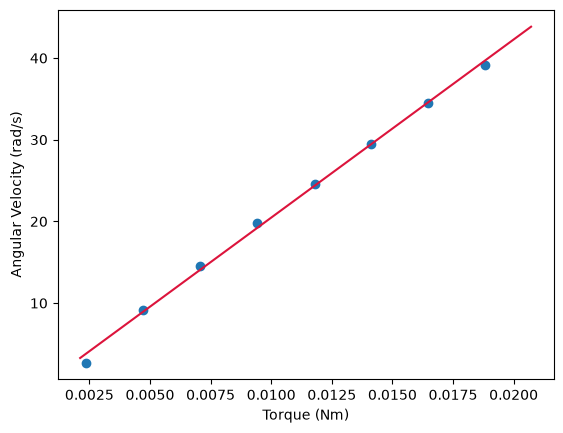

In [26]:
torque_Nm = info.g_acc*info.puley_r.nominal_value*raw["mass_g"].to_numpy()/1000
rad_p_s = raw["ang_velocity_radps"].to_numpy()

reg = stats.linregress(torque_Nm, rad_p_s)


x_line = np.linspace(torque_Nm.min()*0.9, torque_Nm.max()*1.1)
y_line = x_line*reg.slope + reg.intercept

plt.scatter(torque_Nm, rad_p_s)
plt.plot(x_line, y_line, color="crimson")

plt.xlabel("Torque (Nm)")
plt.ylabel("Angular Velocity (rad/s)")
plt.show()

#I need to measure the cilinder radius to contiue

In [31]:
%%latex

$$m = \frac{1}{4 \pi \eta l}({\frac{1}{a²}-\frac{1}{b²}})$$

$$\eta = \frac{1}{4 \pi m l}({\frac{1}{a²}-\frac{1}{b²}})$$


<IPython.core.display.Latex object>

In [27]:
slope_uf = uf(reg.slope, reg.stderr)
print(slope_uf)


eta = (1/4*np.pi*slope_uf*info.height)1/((1/(info.in_height**2) - 1/(info.out_height**2)))


(2.18+/-0.04)e+03
